# Chapter 12. BERT Multi-class — Yelp 5클래스

**목표**: Ch 11(BERT binary, softmax+CE) 셋업을 그대로 두고 **클래스 개수만 2 → 5** 로 늘립니다. 데이터는 Yelp 별점 1-5를 *그대로* 5클래스 분류로 사용 (Ch 3-4·10-11처럼 이진화하지 않음). 이번 챕터는 Ch 5(sklearn multinomial LogReg)의 BERT 버전입니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 12분 (BERT 학습 ~10분 + sklearn 비교 baseline ~30초 + 평가/시각화)

---

## 학습 흐름

1. 🚀 **실습**: Ch 11과 같은 `(num_labels=K, problem_type="single_label_classification")` 셋업, K만 5로. Yelp 별점 1-5를 라벨 0-4 int 인덱스로.
2. 🔬 **해부**: 학습 후 *혼동 행렬* 과 *top-1 확률 분포* 로 클래스별 패턴 확인. 별점 4 ↔ 5 같은 *인접 클래스 혼동* 이 자연스러운지 검증.
3. 🛠️ **클라이맥스**: 같은 노트북 안에서 Ch 5의 sklearn baseline(TF-IDF + multinomial LogReg)을 *inline 재현* 해 BERT 67M 파라미터가 진짜 도움이 되는지 직접 비교.

---

> 📒 **사전 학습 자료**: Ch 5 (sklearn multi-class), Ch 11 (BERT binary 방식 B). 이번 챕터는 self-contained — 다른 챕터의 결과 파일에 의존하지 않습니다.

## 📊 변화추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Activation | Loss |
|---|---|---|---|---|---|---|
| 5 | `LogisticRegression(multinomial)` | `TfidfVectorizer()` | Yelp 5클래스 | (5차원) | softmax | `CrossEntropyLoss` |
| 11 | DistilBERT 파인튜닝 | `AutoTokenizer.from_pretrained(...)` | Yelp 이진화 | `Linear(H, 2)` | softmax | `CrossEntropyLoss` |
| **12 ← 여기** | DistilBERT 파인튜닝 | 같음 | **Yelp 5클래스** | **`Linear(H, 5)`** | softmax | `CrossEntropyLoss` |
| 13 (다음) | DistilBERT 파인튜닝 | 같음 | Yelp + 항목 키워드 (5라벨 multi-label) | `Linear(H, 5)` | sigmoid (per-label) | `BCEWithLogitsLoss` (per-label) |

전체 챕터 표는 [루트 README.md](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표)를 참고하세요.

## 🔄 변경점 (Diff from Ch 11)

| 축 | Ch 11 (binary) | Ch 12 (multi-class) |
|---|---|---|
| **Task** | 이진 분류 | **5-클래스 분류** ← *유일한 변화* |
| `num_labels` | 2 | **5** |
| 데이터 | Yelp 이진화 (별점 3 제외) | **Yelp 별점 1-5 그대로** (제외 없음) |
| 라벨 형식 | int `0` / `1` | **int `0`-`4`** (별점-1) |
| `problem_type` | `single_label_classification` | (그대로) |
| Activation / Loss | softmax / CE | (그대로) |
| 평가 metric | binary precision/recall/F1 + AUC | **accuracy + macro precision/recall/F1 + multi-class AUC (OvR)** |
| 학습 hyperparams (lr, batch, epoch, seed) | 동일 | 동일 |

> **변경점 한 가지 원칙**: Loss·activation·문제 셋업이 그대로 유지되고 *task 차원만 K=2 → K=5* 로 일반화됩니다. Ch 5의 sklearn 챕터에서 본 K=5 셋업이 BERT에 그대로 옮겨오는 모습을 확인하는 것이 핵심.

## 📐 Loss 노트 — `CrossEntropyLoss` 가 K=5 에서 어떻게 보이나

수식은 Ch 4-5·11과 동일:

$$L = -\frac{1}{N}\sum_{i=1}^{N}\log \hat p_{i, y_i} \quad\text{where}\quad \hat p_{i,k} = \dfrac{e^{z_{i,k}}}{\sum_{j=1}^{K} e^{z_{i,j}}}$$

K가 늘어나면 *random baseline 손실* 도 같이 커집니다 — 학습 초반 모델이 logit을 거의 0으로 출력하면 softmax는 균등 $(1/K, \ldots, 1/K)$ 가 되고 정답 클래스의 손실은 $-\log(1/K) = \log K$.

| K | random baseline loss $-\log(1/K)$ | 의미 |
|---|---|---|
| 2 | $\log 2 = 0.693$ | Ch 11 학습 첫 step에서 흔히 보이는 값 |
| 5 | $\log 5 = 1.609$ | **이번 챕터 학습 첫 step의 baseline** |
| 10 | $\log 10 = 2.303$ | 일반적인 ImageNet 1000클래스 학습 비교 |
| 1000 | $\log 1000 = 6.908$ | 학습 시작 직후 손실이 ~7이면 정상 |

**숫자로 감 잡기 (K=5, 정답=클래스 4)** — logits에서 정답 클래스가 얼마나 커야 손실이 얼마인지:

| logits $(z_0, z_1, z_2, z_3, z_4)$ | softmax → $\hat p_4$ | 손실 $-\log \hat p_4$ |
|---|---|---|
| $(0, 0, 0, 0, 0)$ | $0.200$ | **1.609** ← random |
| $(0, 0, 0, 0, 2)$ | $0.541$ | 0.615 |
| $(0, 0, 0, 0, 5)$ | $0.985$ | 0.015 |
| $(5, 0, 0, 0, 0)$ | $0.005$ | **5.310** ← 자신 있게 틀린 케이스 |

**핵심 직감 — softmax는 *상대 logit* 만 본다**: 모든 logit에 같은 상수를 더해도 softmax는 변하지 않음 ($e^{z_k+c} / \sum e^{z_j+c} = e^{z_k}/\sum e^{z_j}$). 즉 K=5 모델이 학습할 때 의미 있는 신호는 *클래스 간 logit 차이* 뿐. *softmax의 4가지 자유도* (K=5에서 K-1=4)만 학습됨.

## 🔤 토크나이저 노트

Ch 11과 완전히 동일 — `distilbert-base-uncased` WordPiece, `max_length=128`. 토크나이저는 라벨 개수에 상관없이 *문장* 만 처리하므로 K가 2든 5든 변화 없습니다. 라벨 개수는 모델의 *분류 헤드* 와 *데이터 라벨 형식* 에서만 다릅니다.

> **다음 챕터(Ch 13)**: 토크나이저 동일. 변하는 건 *라벨 형식* (int 인덱스 → multi-hot 벡터)과 그에 따른 활성화·loss(softmax/CE → sigmoid/BCE per-label).

In [1]:
!pip install -q transformers datasets

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments,
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, roc_auc_score, confusion_matrix,
)
# Ch 5 sklearn baseline 비교용
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CPU runtime — training will be very slow. Switch to T4 recommended.")

PyTorch:        2.11.0+cu128
CUDA available: True
GPU:             Tesla T4


**baseline VRAM**:

In [3]:
!nvidia-smi

Sun Jun 21 22:58:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. 🚀 데이터 — Yelp 별점 1-5 (Ch 5와 동일)

별점 3 제외 같은 전처리 *없이* 그대로 사용. 라벨은 `dataset["label"]` 가 이미 0-4 int 인덱스 (Yelp 데이터셋의 기본 형식).

In [4]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

ds = load_dataset("Yelp/yelp_review_full")
train_full = ds["train"].shuffle(seed=42).select(range(5000))
eval_full  = ds["test"].shuffle(seed=42).select(range(1000))

print(f"train: {len(train_full)} samples")
print(f"eval:  {len(eval_full)} samples")
print(f"\nClass distribution (train):")
for k in range(5):
    n = sum(1 for x in train_full["label"] if x == k)
    print(f"  star {k + 1} (label {k}): {n} ({n / len(train_full):.1%})")

# 첫 샘플 미리보기
print(f"\nFirst sample:")
print(f"  label: {train_full[0]['label']}  (star {train_full[0]['label'] + 1})")
print(f"  text:  {train_full[0]['text'][:200]}...")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/6.72k [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/50000 [00:00<?, ? examples/s]

train: 5000 samples
eval:  1000 samples

Class distribution (train):
  star 1 (label 0): 1017 (20.3%)


  star 2 (label 1): 1027 (20.5%)


  star 3 (label 2): 960 (19.2%)
  star 4 (label 3): 1021 (20.4%)


  star 5 (label 4): 975 (19.5%)

First sample:
  label: 4  (star 5)
  text:  I stalk this truck.  I've been to industrial parks where I pretend to be a tech worker standing in line, strip mall parking lots, and of course the farmer's market.  The bowls are so so absolutely div...


**Ch 11 과의 한 줄 차이**: `out["labels"] = [int(b) for b in batch["binary"]]` → `out["labels"] = [int(l) for l in batch["label"]]`. 별점-1 인덱스를 그대로 라벨로 사용.

In [5]:
def tokenize_fn(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    out["labels"] = [int(l) for l in batch["label"]]   # 0-4 int (Yelp의 라벨 그대로)
    return out

train_tok = train_full.map(tokenize_fn, batched=True).remove_columns(["text", "label"])
eval_tok  = eval_full.map(tokenize_fn,  batched=True).remove_columns(["text", "label"])

print(train_tok)
print(f"\nFirst sample label: {train_tok[0]['labels']}  (int scalar in 0-4)")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 5000
})

First sample label: 4  (int scalar in 0-4)


## 2. 모델 로드 — `num_labels=5` 만 바뀜

Ch 11 셋업에서 K=2 → K=5 한 줄 변화.

In [6]:
STAR_LABELS = {0: "1★", 1: "2★", 2: "3★", 3: "4★", 4: "5★"}

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5,
    problem_type="single_label_classification",
    id2label=STAR_LABELS,
    label2id={v: k for k, v in STAR_LABELS.items()},
)

def param_summary(m):
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    return total, trainable

total, trainable = param_summary(model)
print(f"Parameters:           {total:>13,}  ({total/1e6:.1f} M)")
print(f"Trainable parameters: {trainable:>13,}  ({trainable/total:.1%})")
print(f"Classifier:           {model.classifier}")
print(f"problem_type:         {model.config.problem_type}")
print(f"id2label:             {model.config.id2label}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters:              66,957,317  (67.0 M)
Trainable parameters:    66,957,317  (100.0%)
Classifier:           Linear(in_features=768, out_features=5, bias=True)
problem_type:         single_label_classification
id2label:             {0: '1★', 1: '2★', 2: '3★', 3: '4★', 4: '5★'}


**파라미터 수 비교 — K가 늘어나도 거의 변하지 않습니다**

| 부분 | Ch 11 (K=2) | Ch 12 (K=5) |
|---|---|---|
| DistilBERT body | 66,362,880 | 66,362,880 |
| pre_classifier (`Linear(768→768)`) | 590,592 | 590,592 |
| classifier (`Linear(768→K)`) | 1,538 | **3,845** |
| 합계 | 66,955,010 | **66,957,317** |

분류 헤드만 K에 비례해 늘어나지만 (768·K + K), DistilBERT body가 약 66M이라 K=2 ↔ K=5 전체 차이는 0.003%. **K가 늘어났다고 모델이 *훨씬* 무거워지지는 않는다** 는 점이 multi-class BERT의 매력 중 하나.

In [7]:
!nvidia-smi

Sun Jun 21 22:58:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 3. 학습 — Ch 11과 동일한 hyperparams

Ch 11과 *완전히 같은* learning rate, batch size, epoch 수, seed. 변하는 건 모델의 출력 차원 (5)과 평가 metric의 average 방식 (`"macro"`, multi-class AUC는 `multi_class="ovr"`).

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    # 안정 softmax (K=5)
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs_full = exp / exp.sum(axis=1, keepdims=True)   # (B, 5)
    preds = probs_full.argmax(axis=1)                   # (B,)

    p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    out = {
        "accuracy":        float(accuracy_score(labels, preds)),
        "macro_precision": float(p),
        "macro_recall":    float(r),
        "macro_f1":        float(f1),
    }
    # multi-class AUC: One-vs-Rest, 모든 라벨이 적어도 한 개 등장해야 계산 가능
    try:
        out["auc_ovr"] = float(roc_auc_score(labels, probs_full, multi_class="ovr"))
    except ValueError:
        out["auc_ovr"] = float("nan")
    return out

In [9]:
training_args = TrainingArguments(
    output_dir="./ch12_output",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    fp16=True,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="no",
    report_to="none",
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(f"\nTraining done — mean train loss: {train_result.training_loss:.4f}")
print(f"random baseline loss (K=5): {np.log(5):.4f}")

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Auc Ovr
1,1.099177,1.025679,0.560000,0.561094,0.561534,0.555512,0.861858
2,0.901435,1.000385,0.576000,0.574240,0.577709,0.575556,0.865284



Training done — mean train loss: 1.0706
random baseline loss (K=5): 1.6094


In [10]:
!nvidia-smi

Sun Jun 21 22:59:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             62W /   70W |    1577MiB /  15360MiB |     73%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 4. 🔬 평가 — softmax 확률 분포와 혼동 패턴

Ch 11 패턴 그대로 — `Trainer.predict()` 로 logits를 받아 softmax → argmax. K=5에선 *클래스마다* 정밀도·재현율이 다를 수 있어서 *macro* 평균과 *클래스별* 분해를 같이 봅니다.

In [11]:
# 평가 metric
eval_metrics = trainer.evaluate()
print("BERT 5-class evaluation:")
for k, v in eval_metrics.items():
    if k.startswith("eval_") and isinstance(v, float):
        print(f"  {k:>22}: {v:.4f}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Auc Ovr
0.901435,1.000385,2,0.576000,0.574240,0.577709,0.575556,0.865284


BERT 5-class evaluation:
               eval_loss: 1.0004
           eval_accuracy: 0.5760
    eval_macro_precision: 0.5742
       eval_macro_recall: 0.5777
           eval_macro_f1: 0.5756
            eval_auc_ovr: 0.8653


In [12]:
# logits → softmax → argmax
preds_output = trainer.predict(eval_tok)
logits  = preds_output.predictions               # (B, 5)
labels  = preds_output.label_ids.astype(int)     # (B,)

exp = np.exp(logits - logits.max(axis=1, keepdims=True))
probs_full = exp / exp.sum(axis=1, keepdims=True)  # (B, 5)
preds = probs_full.argmax(axis=1)                  # (B,)

# top-1 확률 (모델이 선택한 클래스의 확률)
top1_prob = probs_full.max(axis=1)
correct = (preds == labels)

print(f"logits shape: {logits.shape}")
print(f"top-1 prob range: [{top1_prob.min():.4f}, {top1_prob.max():.4f}]")
print(f"top-1 prob mean: correct={top1_prob[correct].mean():.4f}, wrong={top1_prob[~correct].mean():.4f}")
print(f"\nFirst 5 samples:")
print(pd.DataFrame({
    "label (star-1)": labels[:5],
    "pred (star-1)":  preds[:5],
    "top-1 prob":     top1_prob[:5].round(4),
    "correct?":       correct[:5],
}).to_string(index=False))

logits shape: (1000, 5)
top-1 prob range: [0.2292, 0.8844]
top-1 prob mean: correct=0.6315, wrong=0.5559

First 5 samples:
 label (star-1)  pred (star-1)  top-1 prob  correct?
              2              4      0.5499     False
              4              3      0.4615     False
              1              0      0.7870     False
              4              3      0.5301     False
              3              3      0.6147      True


### 4-1. 메인 그림 — 혼동 행렬 (`seaborn.heatmap`)

5클래스 분류의 *어디에서 혼동이 일어나는지* 한눈에 보는 가장 강력한 도구입니다. 행은 정답 별점, 열은 예측 별점, 셀의 숫자는 해당 (정답, 예측) 조합의 샘플 수.

**봐야 할 패턴**

- **대각선** (정답=예측): 색이 진할수록 그 클래스가 잘 맞은 것.
- **인접 클래스 혼동** (`(2★, 3★)`, `(4★, 5★)` 등): 별점은 *순서가 있는* 라벨이라 인접 별점끼리 헷갈리는 건 자연스럽습니다.
- **먼 클래스 혼동** (`(1★, 5★)`): 이건 진짜 오류. 데이터에 라벨 노이즈가 있거나 모델 학습이 부족한 신호.

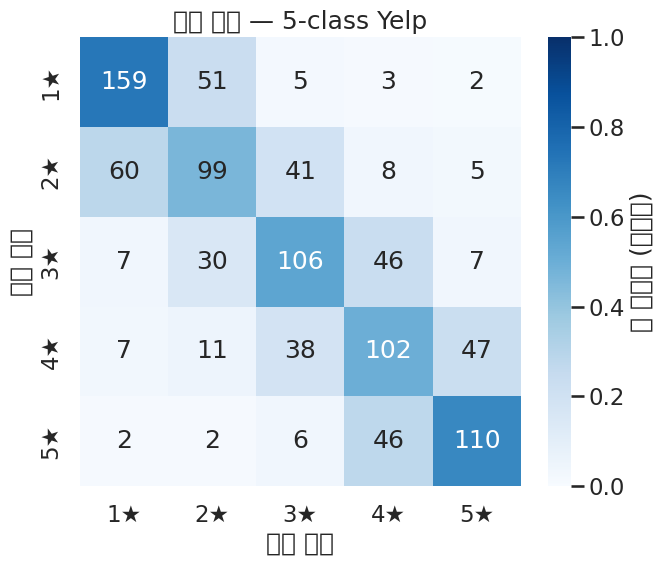

In [13]:
sns.set_theme(style="white", context="talk")

cm = confusion_matrix(labels, preds, labels=list(range(5)))
# 정답 라벨별 정규화 — 각 행 합이 1이 되어 *재현율* 을 직접 읽을 수 있음
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm_norm, annot=cm, fmt="d",                       # 색은 비율, 숫자는 raw count
    cmap="Blues", vmin=0, vmax=1,
    xticklabels=[STAR_LABELS[k] for k in range(5)],
    yticklabels=[STAR_LABELS[k] for k in range(5)],
    cbar_kws={"label": "행 정규화 (재현율)"}, ax=ax,
)
ax.set_xlabel("예측 별점")
ax.set_ylabel("실제 별점")
ax.set_title("혼동 행렬 — 5-class Yelp")
plt.tight_layout()
plt.show()

**해석 가이드**

- 색의 진하기는 *행 정규화* (정답 클래스 안에서의 비율) — 대각선 셀의 색이 그 클래스의 *재현율* 입니다.
- 숫자는 *원본 카운트* 라 클래스별 표본 크기도 같이 보입니다 — 어떤 클래스에 모델 평가 표본이 적으면 통계적 노이즈가 큼을 인지.
- `1★ → 2★` 또는 `4★ → 5★` 같은 *±1 이웃 오류* 가 가장 흔할 것 — 별점 회귀에 가까운 task의 자연스러운 양상. 별점 *3★* 이 가장 어려울 가능성이 큰데, 이는 사람도 1★/2★보다 헷갈리는 *중간* 평가이기 때문.

### 4-2. 보조 그림 — top-1 확률의 분포 (정답/오답 갈림)

K=5에서는 *어느 한 클래스에 압도적인 자신감* 이 있는 경우와 *2-3 클래스 사이에서 갈피를 못 잡는* 경우가 나뉩니다. 정답·오답을 구분해 그리면 모델 자신감이 *얼마나 calibration 됐는지* 가 드러납니다.

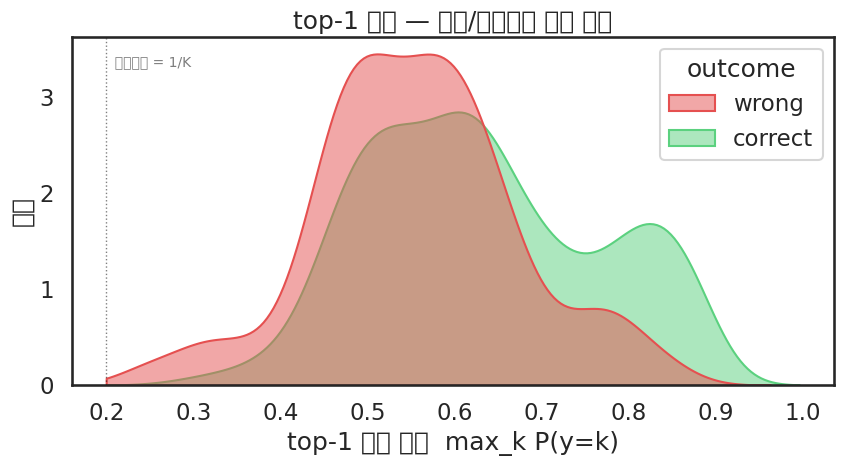

In [14]:
df_top = pd.DataFrame({
    "top1_prob": top1_prob,
    "outcome":   np.where(correct, "correct", "wrong"),
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.kdeplot(
    data=df_top, x="top1_prob", hue="outcome",
    fill=True, common_norm=False, alpha=0.5,
    palette={"correct": "#5BD17F", "wrong": "#E55050"},
    clip=(1/5, 1.0), ax=ax,
)
ax.axvline(1/5, color="black", lw=1.0, ls=":", alpha=0.5)
ax.text(1/5, ax.get_ylim()[1]*0.95, "  균등분포 = 1/K", va="top", fontsize=10, alpha=0.6)
ax.set_title("top-1 확률 — 정답/오답으로 나눈 분포")
ax.set_xlabel("top-1 예측 확률  max_k P(y=k)")
ax.set_ylabel("밀도")
plt.tight_layout()
plt.show()

**해석**

- **잘 학습된 모델**은 *correct 곡선이 1.0 가까이* 몰리고 *wrong 곡선은 더 낮은 영역* (0.4-0.7)에 퍼져 있습니다. 모델이 틀릴 때는 *덜 자신 있게* 틀려야 calibration이 좋다는 뜻.
- **두 곡선이 1.0 근처에서 함께 압착** 되어 있으면 → 모델이 *틀린 답에도 매우 자신* 있는 *over-confident* 상태. 별점 ±1 이웃 오류가 많을수록 이 현상이 도드라짐.
- **correct 곡선이 0.5-0.8 근처에 머무르면** → 모델이 *정답을 알면서도 망설이는* 상태. 학습이 부족하거나 task가 본질적으로 모호한 경우.

In [15]:
# 클래스별 분류 리포트 (precision/recall/F1 클래스 단위)
print(classification_report(
    labels, preds,
    target_names=[STAR_LABELS[k] for k in range(5)],
    digits=4, zero_division=0,
))

              precision    recall  f1-score   support

          1★     0.6766    0.7227    0.6989       220
          2★     0.5130    0.4648    0.4877       213
          3★     0.5408    0.5408    0.5408       196
          4★     0.4976    0.4976    0.4976       205
          5★     0.6433    0.6627    0.6528       166

    accuracy                         0.5760      1000
   macro avg     0.5742    0.5777    0.5756      1000
weighted avg     0.5729    0.5760    0.5740      1000



## 5. 🛠️ 클라이맥스 — sklearn TF-IDF + LogReg 와의 비교 (Ch 5의 BERT 검증)

같은 데이터에 Ch 5 셋업(TF-IDF + multinomial LogReg)을 *이 노트북 안에서* 다시 학습해 비교합니다. **BERT 67M 파라미터가 진짜로 도움이 되는가?** 가 이 비교의 핵심 질문 — sklearn은 GPU 없이도 몇 초 만에 끝나기 때문에 self-contained로 부담 없이 포함됩니다.

In [16]:
# Ch 5 셋업 재현 — TF-IDF + multinomial LogReg
texts_train  = list(train_full["text"])
labels_train = list(train_full["label"])
texts_eval   = list(eval_full["text"])
labels_eval  = list(eval_full["label"])

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vec.fit_transform(texts_train)
X_eval  = vec.transform(texts_eval)

clf = LogisticRegression(max_iter=2000, n_jobs=-1)   # 최신 sklearn은 multinomial이 default for multi-class
clf.fit(X_train, labels_train)

probs_sk = clf.predict_proba(X_eval)                 # (B, 5)
preds_sk = probs_sk.argmax(axis=1)                   # (B,)

acc_sk = float(accuracy_score(labels_eval, preds_sk))
ps, rs, f1s, _ = precision_recall_fscore_support(labels_eval, preds_sk, average="macro", zero_division=0)
auc_sk = float(roc_auc_score(labels_eval, probs_sk, multi_class="ovr"))

print(f"sklearn TF-IDF + LogReg:")
print(f"  vocabulary size:    {len(vec.vocabulary_):,}")
print(f"  trained parameters: {clf.coef_.size + clf.intercept_.size:,}  (~{clf.coef_.size/1e3:.0f} K)")
print(f"  accuracy:           {acc_sk:.4f}")
print(f"  macro F1:           {f1s:.4f}")
print(f"  AUC (OvR):          {auc_sk:.4f}")

sklearn TF-IDF + LogReg:
  vocabulary size:    20,000
  trained parameters: 100,005  (~100 K)
  accuracy:           0.5420
  macro F1:           0.5380
  AUC (OvR):          0.8420


### 5-1. 두 모델의 metric 표 비교

In [17]:
metrics_bert = {
    k.replace("eval_", ""): v for k, v in eval_metrics.items()
    if k.startswith("eval_") and isinstance(v, float)
}
metrics_sk = {
    "accuracy":        acc_sk,
    "macro_precision": float(ps),
    "macro_recall":    float(rs),
    "macro_f1":        float(f1s),
    "auc_ovr":         auc_sk,
}

common = [k for k in metrics_bert if k in metrics_sk]
cmp = pd.DataFrame({
    "metric":             common,
    "sklearn (TF-IDF)":   [metrics_sk[k]   for k in common],
    "BERT":               [metrics_bert[k] for k in common],
})
cmp["BERT - sklearn"] = cmp["BERT"] - cmp["sklearn (TF-IDF)"]
print(cmp.round(4).to_string(index=False))

         metric  sklearn (TF-IDF)   BERT  BERT - sklearn
       accuracy            0.5420 0.5760          0.0340
macro_precision            0.5377 0.5742          0.0365
   macro_recall            0.5410 0.5777          0.0367
       macro_f1            0.5380 0.5756          0.0376
        auc_ovr            0.8420 0.8653          0.0233


### 5-2. 두 모델의 혼동 행렬 비교

같은 평가 데이터에 sklearn은 어디서, BERT는 어디서 헷갈리는지 *나란히* 봅니다.

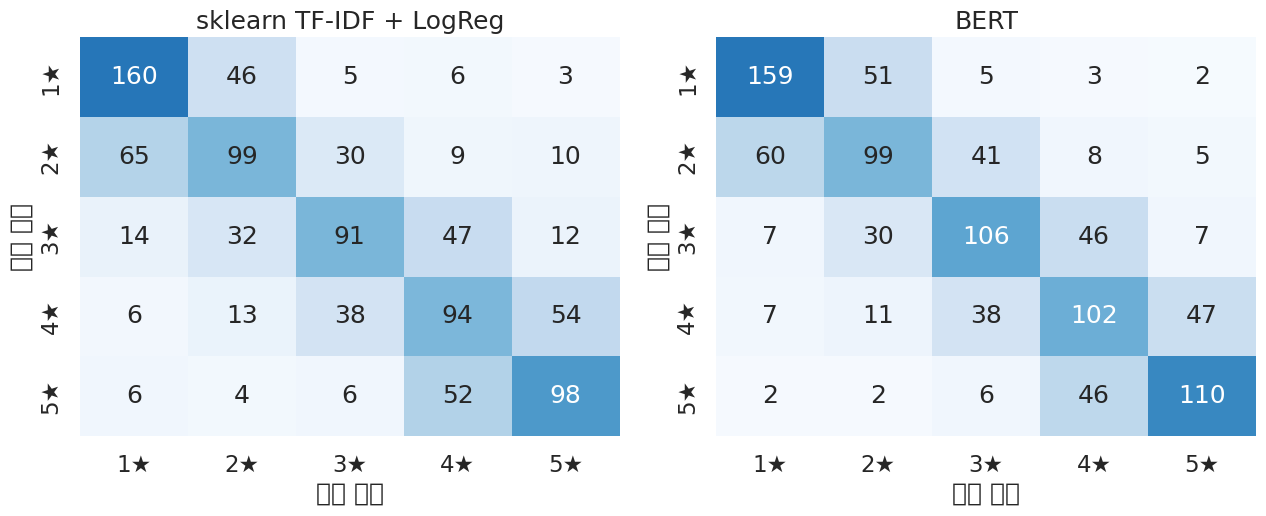

In [18]:
cm_bert = confusion_matrix(labels, preds, labels=list(range(5)))
cm_sk   = confusion_matrix(labels_eval, preds_sk, labels=list(range(5)))

cm_bert_n = cm_bert / cm_bert.sum(axis=1, keepdims=True)
cm_sk_n   = cm_sk   / cm_sk.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, cm_n, cm_raw, title in [
    (axes[0], cm_sk_n,   cm_sk,   "sklearn TF-IDF + LogReg"),
    (axes[1], cm_bert_n, cm_bert, "BERT"),
]:
    sns.heatmap(
        cm_n, annot=cm_raw, fmt="d", cmap="Blues", vmin=0, vmax=1,
        xticklabels=[STAR_LABELS[k] for k in range(5)],
        yticklabels=[STAR_LABELS[k] for k in range(5)],
        cbar=False, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("예측 별점")
    ax.set_ylabel("실제 별점")
plt.tight_layout()
plt.show()

**해석 가이드**

- *대각선이 더 진하면* 그 모델이 더 잘 맞춘 것.
- *인접 클래스 혼동(±1)* 은 두 모델 모두에서 가장 흔할 것 — 별점이 *순서형* 라벨이라 자연스럽습니다.
- BERT가 sklearn 대비 가장 크게 개선되는 영역은 보통 **3★ (중간 별점)**: 단어 빈도만으로는 *애매한 칭찬·비판이 섞인* 리뷰를 구분하기 어렵지만, BERT는 attention으로 문맥을 보기 때문.
- 만약 BERT가 sklearn보다 *모든 셀에서* 비슷하거나 더 나쁘다면 → 학습량 부족 신호. epoch을 늘리거나 lr을 조정.

## 📦 이번 챕터에 등장한 라이브러리·함수

| 이름 | 한 줄 설명 | 다음 챕터에서 |
|---|---|---|
| `AutoModelForSequenceClassification(num_labels=5, problem_type="single_label_classification")` | Ch 11 셋업에서 K만 5로 | Ch 13에서 `multi_label_classification` 으로 K=5 multi-label 매핑 |
| `sklearn.metrics.confusion_matrix` | 혼동 행렬 raw 카운트 | 분류 챕터마다 사용 |
| `seaborn.heatmap(annot=..., fmt="d")` | 혼동 행렬 시각화 (색은 비율, 숫자는 카운트) | 분류 챕터마다 동일 패턴 |
| `roc_auc_score(..., multi_class="ovr")` | multi-class AUC를 One-vs-Rest로 계산 | Ch 13·15-18에서 multi-label / multi-class 평가 |
| `precision_recall_fscore_support(..., average="macro")` | 클래스 불균형에서 모든 클래스에 같은 가중치 | 분류 챕터마다 등장 |

## 🎯 체크포인트 질문

1. K=5에서 학습 시작 시 train loss가 약 1.6 정도라면 모델이 무엇을 학습한 상태인가요?
2. *macro* F1과 *micro* (= accuracy) 의 차이가 크다면 무엇을 의심해야 하나요?
3. 혼동 행렬에서 ±1 이웃 클래스 혼동이 많다는 것은 무엇을 시사합니까?
4. BERT의 67M 파라미터가 sklearn의 ~100K 파라미터(TF-IDF 5클래스)보다 정확도가 *몇 %p* 높다면 그 비용을 감수할 가치가 있다고 판단할 수 있나요?

## ❓ FAQ

### Q1. (실무) BERT multi-class에서 클래스 불균형이 심하면 어떻게 하나요?

가장 흔한 처치 두 가지:

1. **`class_weight` 적용** — `Trainer.compute_loss` 를 오버라이드해서 `CrossEntropyLoss(weight=...)` 를 명시적으로 사용. 가중치는 보통 `1 / class_count` 의 정규화 형태.

```python
from torch import nn

weights = torch.tensor([1.0, 1.5, 3.0, 1.2, 0.8]).to("cuda")  # 클래스별 가중치
loss_fn = nn.CrossEntropyLoss(weight=weights)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss
```

2. **데이터 단계 oversampling/undersampling** — `imbalanced-learn` 의 `RandomOverSampler` 같은 도구로 학습 데이터를 균형있게. 단순하고 효과적.

### Q2. (이론) softmax는 왜 *상대 logit* 만 보나요? 그러면 절대 logit 값에 의미가 없나요?

수식으로:

$$\mathrm{softmax}(z + c \cdot \mathbf 1)_k = \dfrac{e^{z_k + c}}{\sum_j e^{z_j + c}} = \dfrac{e^{z_k} e^c}{e^c \sum_j e^{z_j}} = \mathrm{softmax}(z)_k$$

모든 logit에 같은 상수 $c$ 를 더해도 softmax 출력이 동일합니다. 즉 K-차원 logit 벡터의 K-1 자유도만 학습됨 (K=5에선 4자유도).

**절대 logit 값은 *학습 신호 크기* 를 결정**합니다. logit 값이 크면 (예: $|z_k| \gg 1$) softmax가 한쪽에 압착되어 gradient가 작아지고, 작으면 (예: $|z_k| \approx 0$) gradient가 균등해 모든 클래스가 학습됩니다. 학습 초기엔 logit이 작아 모든 클래스에 신호가 가는 게 좋고, 후반엔 logit이 커져 confident한 결정을 내리게 됩니다.

### Q3. (실무) eval 데이터에 어떤 클래스가 *하나도* 안 나타나면 AUC 계산이 실패하는데 어떻게 하나요?

`roc_auc_score(multi_class="ovr")` 는 *각 클래스에 대해* positive/negative를 나누어 AUC를 계산하는데, positive 샘플이 0개인 클래스가 있으면 AUC를 정의할 수 없어서 `ValueError` 가 납니다.

처치는 두 가지:

1. **try/except로 NaN 반환** — 이번 챕터의 `compute_metrics` 가 사용하는 패턴. 학습 자체엔 영향 없음.
2. **eval 데이터를 더 모아서 모든 클래스가 등장하도록** — 운영 환경에선 이게 정석. 평가의 통계적 신뢰도 자체에도 도움.

평가 셋이 1,000건 정도면 5클래스가 모두 등장할 가능성이 높지만, 각 클래스 표본이 ~200건 안팎이라 통계 잡음이 큽니다. 가능하면 평가 셋을 늘리세요.

### Q4. (이론) 별점 1-5는 *순서형 라벨* 인데 왜 회귀(Ch 9) 대신 분류(Ch 12)로 푸나요?

둘 다 가능하고 각각 장단점이 있습니다.

| | 회귀 (Ch 9 방식) | 분류 (Ch 12 방식) |
|---|---|---|
| 라벨 의미 | 별점이 *연속* 값 (1.0-5.0) | 별점이 *5개의 명목 클래스* |
| 손실 | MSE — 4★ vs 5★ 차이 = (1)² = 1 | CE — 4★ vs 5★ 차이도 1★ vs 5★ 차이도 *같은 손실* |
| 출력 | scalar 1.0-5.0 | (5,) 확률 벡터 |
| ±1 인접 오류 페널티 | 작음 | 크지 않음 (정답 확률이 어느 정도 있으면) |
| 모델이 *순서* 를 인지? | **자동으로 인지** | 명시적으론 인지 안 함 (학습 데이터 통계로 우회 학습) |

**언제 어느 방식을?** 별점이 *진짜 순서형이고 distance가 의미있다* (1★→5★는 1★→2★보다 4배 더 부정적) 면 회귀가 자연스럽습니다. 별점이 *카테고리에 가까워서 distance 의미가 약하다* (예: 영화 장르 분류) 면 분류가 자연스럽습니다.

**ordinal regression** 이라는 별도의 분야가 있어 *순서형* 의 특수 구조를 살리는 손실(예: cumulative link)을 씁니다. 입문 수준에선 다루지 않습니다.

### Q5. (실무) BERT가 sklearn 대비 *조금만* 좋다면 BERT를 안 쓰는 게 나을까요?

5-10%p 정도 정확도 향상이라면 trade-off:

- **inference 비용**: BERT는 GPU 권장 (CPU에선 ~50배 느림). sklearn은 CPU로 충분. 운영 비용 차이 5-10배.
- **메모리**: BERT 모델 ~250MB 디스크, ~500MB 메모리. sklearn은 ~10MB.
- **학습 시간**: BERT는 GPU 5-10분. sklearn은 CPU 5-30초. 실험 cycle 100배 차이.
- **유연성**: BERT는 fine-tune이 가능 (도메인 특화 추가 학습). sklearn은 *처음부터 다시* 학습.

단순 *정확도-vs-비용* 만 보면 **5%p 이내 차이면 sklearn**, **10%p 이상이면 BERT 고려** 같은 룰이 무난합니다. 별점 task처럼 *단어 빈도가 강한 신호* 인 도메인은 sklearn 유리, *부정·반어·다단계 추론* 이 중요한 NLI/감성분석 도메인은 BERT 유리.

**그런데 정확도 너머의 가치가 있습니다.** 다음 시나리오에서는 정확도 차이가 *2-3%p* 만 나도 BERT가 압도적으로 유리합니다 — sklearn으로는 *애초에 불가능* 하거나 별도 파이프라인을 통째로 다시 만들어야 하기 때문.

**(1) 새 도메인으로의 빠른 적응 — *transfer learning***

영어 일반 리뷰로 학습한 BERT를 *의료 환자 리뷰* 100-500건만으로 fine-tune해 즉시 도메인 모델을 얻을 수 있습니다. sklearn은 도메인이 바뀌면 *어휘 통계가 처음부터 다시* — 의료 용어 빈도가 일반 리뷰와 달라 TF-IDF가 새 분포에서 학습돼야 하고, 100건은 통계적으로 너무 적습니다.

```python
# 일반 리뷰 BERT 체크포인트를 의료 도메인으로 추가 학습
model = AutoModelForSequenceClassification.from_pretrained("yelp-finetuned-bert")
model.train_on(medical_reviews_500)   # ← 적은 데이터로도 잘 됨 (사전학습+yelp 지식 보존)
```

**(2) 다국어 / cross-lingual — 같은 코드로 한국어·일본어·영어**

`xlm-roberta-base` 같은 다국어 BERT는 *동일 모델 + 동일 코드* 로 100+ 언어 동작. 영어 Yelp로 학습한 모델이 *한국어 리뷰에도 그대로 generalize* 합니다 (zero-shot cross-lingual transfer). sklearn은 언어마다 토크나이저(형태소 분석기), 불용어 사전, TF-IDF vocabulary를 *각각* 만들어야 합니다.

```python
# 영어로 학습한 모델을 한국어 평가 셋에 그대로
tok = AutoTokenizer.from_pretrained("xlm-roberta-base")     # 100+ 언어 공통
model.predict(tok("이 식당 음식이 정말 별로였어요"))     # ← 한 번도 한국어 학습 안 했지만 동작
```

**(3) 분류 너머의 task로 확장 — 같은 백본, 다른 헤드**

같은 `distilbert-base-uncased` 본체로:

| Task | 모델 클래스 | 예시 |
|---|---|---|
| 분류 (이번 챕터) | `AutoModelForSequenceClassification` | 별점 1-5 분류 |
| 토큰 분류 (NER) | `AutoModelForTokenClassification` | "*Bob* 가 *Apple* 에서 *iPhone* 을 샀다" → 사람/회사/제품 추출 |
| 질의응답 | `AutoModelForQuestionAnswering` | "이 리뷰의 만족도는?" 답: "음식은 좋지만 서비스가" |
| 텍스트 생성 | `AutoModelForCausalLM` | 자동 답변 생성 |
| 임베딩 | `AutoModel` (CLS hidden state) | 문장 의미 벡터 |

sklearn LogReg는 *분류 한 가지* 만. 다른 task는 모델 자체가 달라져야 합니다.

**(4) 임베딩 기반 의미 검색·중복 제거**

BERT [CLS] 임베딩은 *문장 의미를 768-dim 벡터* 로 만듭니다. 단어가 달라도 *의미가 비슷하면 가까운 벡터*. TF-IDF는 *같은 단어* 가 있어야 매칭 — "맛있다" 와 "delicious" 는 거리 1, BERT는 거의 거리 0.

```python
# 의미 기반 중복 리뷰 찾기
emb1 = model(tok("맛있고 친절했어요"))[:, 0, :]        # CLS
emb2 = model(tok("음식 훌륭하고 직원 좋았음"))[:, 0, :]
cos_sim(emb1, emb2)   # ≈ 0.92 (의미 유사)
# TF-IDF로는 cos_sim ≈ 0.0 (공통 단어 없음)
```

리뷰 수만 건 중 *의미 중복* 을 제거하거나, 새 리뷰가 들어왔을 때 *비슷한 과거 리뷰* 를 검색하는 시스템 — sklearn으로는 거의 불가능.

**(5) Zero-shot 분류 — 학습 데이터 없이도 동작**

NLI(natural language inference)로 fine-tune된 BERT (`facebook/bart-large-mnli` 등)는 *임의의 라벨* 에 대해 학습 *없이* 분류합니다.

```python
from transformers import pipeline
zsc = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")
zsc("음식이 별로였다", candidate_labels=["positive", "negative", "neutral"])
# {"labels": ["negative", "neutral", "positive"], "scores": [0.91, 0.07, 0.02]}
```

새 라벨 카테고리가 생길 때마다 학습 데이터 라벨링 비용이 없습니다. 빠른 프로토타이핑·콜드스타트에 강력. sklearn은 *학습 데이터 필수*.

**정리** — sklearn은 *오늘의 task* 를 가장 빠르고 싸게 푸는 도구. BERT는 *task 자체가 진화하거나, 도메인이 늘어나거나, 분류 외 응용으로 확장될 때* 의 자산. 정확도 비교만으로 BERT 가치를 판단하기 부족한 이유입니다.

### Q6. (실무) 한 모델로 *binary와 5-class를 동시에* 풀 수 있나요?

**multi-task learning** 이라는 패턴으로 가능합니다.

```python
class MultiTaskModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.head_binary = nn.Linear(768, 2)    # binary head
        self.head_5class = nn.Linear(768, 5)    # 5-class head

    def forward(self, **inputs):
        h = self.backbone(**inputs).last_hidden_state[:, 0]   # CLS
        return {"binary": self.head_binary(h), "5class": self.head_5class(h)}

# loss는 두 head의 CE를 *합* (또는 가중합)
loss = ce(out["binary"], y_binary) + ce(out["5class"], y_5class)
```

DistilBERT body가 *공유* 되어 두 task가 서로의 학습에 도움을 줍니다. Ch 14 (Auxiliary Loss)에서 비슷한 패턴을 본격적으로 다룹니다.

## 🚀 삽질 코너 (선택)

다음 코드를 돌려보면 어떤 에러가 날까요?

```python
# 라벨을 *원-핫* 으로 두고 single_label_classification 모델에 학습 시도
def tokenize_wrong(batch):
    out = tokenizer(batch["text"], truncation=True, max_length=128)
    onehot = []
    for l in batch["label"]:
        v = [0.0] * 5
        v[l] = 1.0
        onehot.append(v)
    out["labels"] = onehot   # ← 잘못: shape (B, 5) float
    return out
```

힌트: `single_label_classification` + `CrossEntropyLoss` 가 받는 라벨은 *int 인덱스 1차원 텐서* (shape `(B,)`)인데 위 코드는 *(B, 5)* 형태를 넘깁니다. multi-label 형식의 라벨을 single-label 모델에 넣으려는 흔한 실수.

## 다음 챕터 예고

**Chapter 13. BERT Multi-label — Yelp 항목 키워드**

- 같은 BERT, 같은 데이터에 *항목(food/service/price/ambiance/location) 키워드 자동 라벨링* 추가
- `num_labels=5` 그대로 (Ch 12와 같음), 단 `problem_type="multi_label_classification"` 으로 전환
- Activation은 (per-label) sigmoid, Loss는 (per-label) `BCEWithLogitsLoss`
- 한 리뷰에 *여러 항목이 동시에 등장* 할 수 있음 — single-label과 본질적으로 다른 task
- Ch 6의 sklearn `OneVsRestClassifier(LogisticRegression)` 의 BERT 버전

> **변하는 축**: Ch 12 → Ch 13 은 *Loss 축* (CE → BCE per-label)이 변합니다 — task가 *single-label* 에서 *multi-label* 로 바뀌는 것이 본질이고 그에 맞춰 loss/activation/라벨 형식이 동시에 따라옵니다.